In [ ]:
# Import packages
import os
from pathlib import Path

os.chdir(Path.cwd().parent)
project_dir = Path("/home/mcaskey/10XvParse/")

import anndata as ad
import scanpy as sc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
hto_data = ad.read_h5ad(project_dir / "Data/Analysis_2/10x_hashtags/kb_python/all_out/counts_unfiltered/adata.h5ad")
adata = ad.read_h5ad(project_dir / "Data/Analysis_2/10x/kb_python/all_out/counts_unfiltered/adata.h5ad")

In [3]:
print(len(set(hto_data.obs_names) & set(adata.obs_names)) / len(set(adata.obs_names)))
print(len(set(hto_data.obs_names) & set(adata.obs_names)) / len(set(hto_data.obs_names)))

0.01048615142536947
0.10610111091308738


In [4]:
hto_data.obs["n_counts"] = hto_data.X.sum(axis=1)
adata.obs["n_hto_counts"] = hto_data.obs["n_counts"]
adata.obs["n_counts"] = adata.X.sum(axis=1)

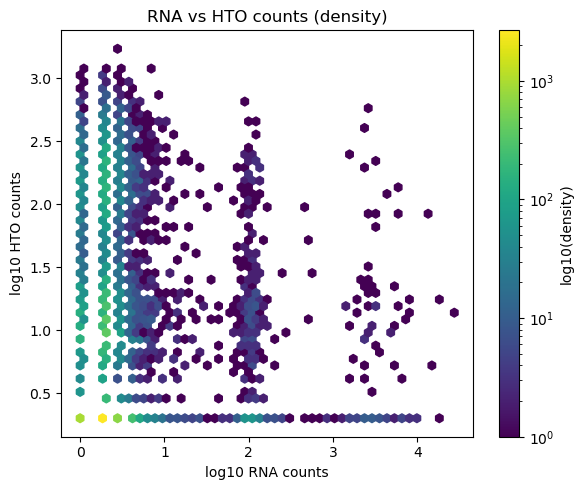

In [5]:
x = np.log10(adata.obs['n_counts'] + 1)
y = np.log10(adata.obs['n_hto_counts'] + 1)

plt.figure(figsize=(6, 5))
hb = plt.hexbin(x, y, gridsize=50, bins='log')
plt.colorbar(hb, label='log10(density)')

plt.xlabel('log10 RNA counts')
plt.ylabel('log10 HTO counts')
plt.title('RNA vs HTO counts (density)')

plt.tight_layout()
plt.show()

In [6]:
common = adata.obs_names.intersection(hto_data.obs_names)
adata = adata[common].copy()
hto_data = hto_data[common].copy()

# Put hashtag counts into adata.obs
hto_df = pd.DataFrame(
    hto_data.X.toarray() if hasattr(hto_data.X, "toarray") else hto_data.X,
    index=hto_data.obs_names,
    columns=hto_data.var_names
)

adata.obs = adata.obs.join(hto_df)

# Run HashSolo using the hashtag column names
sc.external.pp.hashsolo(adata, cell_hashing_columns=list(hto_data.var_names))

Please cite HashSolo paper:
https://www.cell.com/cell-systems/fulltext/S2405-4712(20)30195-2


In [7]:
demux_pd = adata.obs[["Classification"]]
print(demux_pd["Classification"].value_counts())

Classification
10x_A2     4601
10x_B2     3939
10x_B1     2137
Doublet    1856
10x_A1     1755
Name: count, dtype: int64


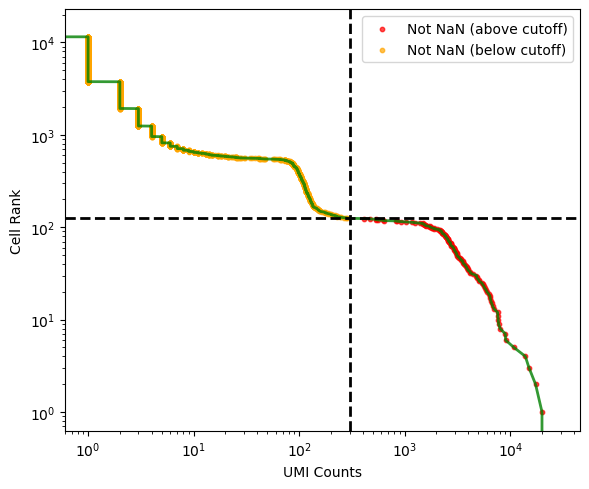

In [8]:
cutoff = 301

# --- Compute total counts per cell ---
counts = np.array(adata.X.sum(axis=1)).flatten()

# --- Sort cells by counts (descending) ---
sorted_idx = np.argsort(counts)[::-1]
knee = counts[sorted_idx]
cell_rank = np.arange(len(knee))

# --- Compute number of cells above cutoff (robust) ---
num_cells = np.sum(knee > cutoff)

# --- Get NaN mask and reorder ---
nan_mask = ~adata.obs['Classification'].isna().values
nan_sorted = nan_mask[sorted_idx]

# --- Plot ---
fig, ax = plt.subplots(figsize=(6, 5))

# Background: all cells (faint)
ax.scatter(knee, cell_rank, s=2, alpha=0.2, color='gray')

# Highlight NaN cells (above cutoff)
ax.scatter(
    knee[nan_sorted & (knee > cutoff)],
    cell_rank[nan_sorted & (knee > cutoff)],
    s=10,
    color='red',
    alpha=0.7,
    label='Not NaN (above cutoff)'
)

# Highlight NaN cells (below cutoff)
ax.scatter(
    knee[nan_sorted & (knee <= cutoff)],
    cell_rank[nan_sorted & (knee <= cutoff)],
    s=10,
    color='orange',
    alpha=0.7,
    label='Not NaN (below cutoff)'
)

# Knee curve (optional overlay for emphasis)
ax.loglog(knee, cell_rank, linewidth=2, color="green", alpha=0.8)

# Cutoff lines
ax.axvline(x=cutoff, linewidth=2, color="black", linestyle="--")
ax.axhline(y=num_cells, linewidth=2, color="black", linestyle="--")

# Labels and title
ax.set_xlabel("UMI Counts")
ax.set_ylabel("Cell Rank")

ax.legend()
plt.tight_layout()
plt.show()

In [9]:
hto_config_dir = project_dir / "Configs/Analysis_2/10x"
Path(project_dir / hto_config_dir).mkdir( exist_ok=True)
demux_pd.to_csv(hto_config_dir / "hto_demultiplexed.csv")